## Modulación FSK de Sunde (M=2, N=1)

In [66]:
#importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [67]:
#Se definen parámetros 

#Probabilidad del bits
p0 = 1/4
p1 = 3/4

#Número de bits de la secuencia a generar
N=5

#Parámetros de modulación 2-FSK
formato='polar' 
M=2
n = int(np.log2(M))
Tb = 0.001
fb=1/Tb
#parámetros para la gráfica de señales
fmuestreo = 1000000
fc = 2*fb
Ac=1


In [68]:
def generador_secuencia(n, p0, p1, semilla=None):
    # validación
    if not np.isclose(p0 + p1, 1):
        raise ValueError("Las probabilidades deben cumplir: p0 + p1 = 1")
    rng = np.random.default_rng(semilla)
    return rng.choice([0, 1], size=n, p=[p0, p1])

# ejemplo
secuencia = generador_secuencia(N, p0, p1, semilla=42)
print(f"Secuencia generada: {secuencia}")

Secuencia generada: [1 1 1 1 0]


In [69]:
def gray_code(n):
    """Genera códigos Gray de n bits"""
    if n == 0:
        return ['']
    prev = gray_code(n-1)
    return ['0' + code for code in prev] + ['1' + code for code in reversed(prev)]

## Convertidor de Datos

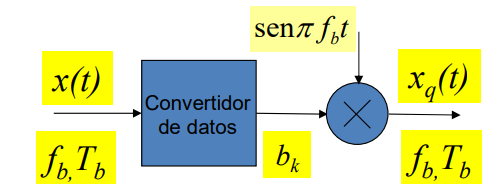

*Fuente: Material Telecomunicaciones Digitales - UPC [Autor:Dr. Carlos Valdez]*

In [70]:
def convertidor_datos(bits, M=2, formato='polar'):
    n = int(np.log2(M))
    
    # asegurar múltiplo de n
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    # agrupar bits
    grupos = bits.reshape(-1, n)
    
    # generar código Gray
    gray = gray_code(n)
    
    # mapping: binario -> índice Gray
    mapping = {tuple(int(b) for b in gray[i]): i for i in range(M)}
    
    # convertir grupos a índices
    indices = [mapping[tuple(grupo)] for grupo in grupos]
    indices = np.array(indices)
    
    #frecuencias
    if formato == 'polar':
        # niveles simétricos
        niveles = 2*indices - (M - 1)
    else:
        raise ValueError("Formato debe ser 'polar'")
    
    return niveles


bk = convertidor_datos(secuencia, M, formato='polar')
print(f"Secuencia x(t): {secuencia}")
print(f"Símbolos bk: {bk} ")

Secuencia x(t): [1 1 1 1 0]
Símbolos bk: [ 1  1  1  1 -1] 


## Formas de Onda x(t), xi(t) xq(t), xc(t)
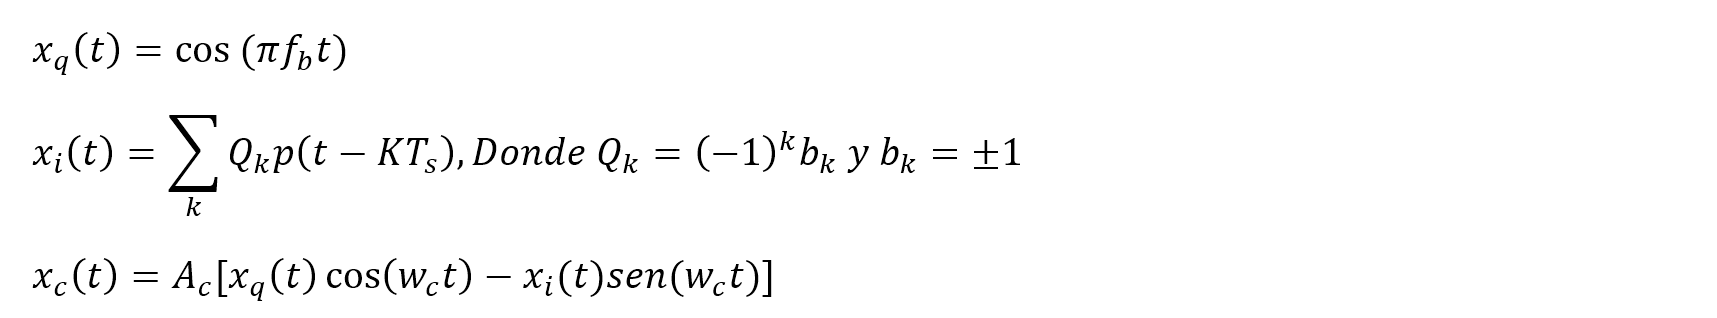

In [71]:
def pulso_rectangular(t, Tb, fmuestreo):
    eps = 1/(2*fmuestreo)
    return np.where((t >= -eps) & (t < Tb - eps), 1.0, 0.0)

def pulso_elemental(t, Tb, fmuestreo): 
    fb=1/Tb
    return np.sin(np.pi*fb*t)*pulso_rectangular(t,Tb, fmuestreo)
    
def xq(simbolos, Tb, fmues):
    s = np.zeros_like(t, dtype=float)
    for k, b_k in enumerate(simbolos):
        s += ((-1)**k)*b_k * pulso_elemental(t - k*Tb, Tb, fmues)
    return  s

    
# señal banda base
Ns = int(Tb * fmuestreo)

t = np.arange(len(bk) * Ns) / fmuestreo


#aux = np.array([1, -1, -1, 1])

#pulso rectangular
rectangular =pulso_rectangular(t, Tb, fmuestreo)

#Pulso elemental
elemental =pulso_elemental(t, Tb, fmuestreo)

#señal en cuadratura
x_q = xq(bk, Tb, fmuestreo)

#Señal en fase
x_i = np.cos(np.pi*fb*t)

# portadoras
portadora1 = np.cos(2 * np.pi * fc * t)
portadora2 = -np.sin(2 * np.pi * fc * t)

#Señal modulada
x_c=x_i*portadora1+x_q*portadora2




# señal modulada
#x = s * portadora

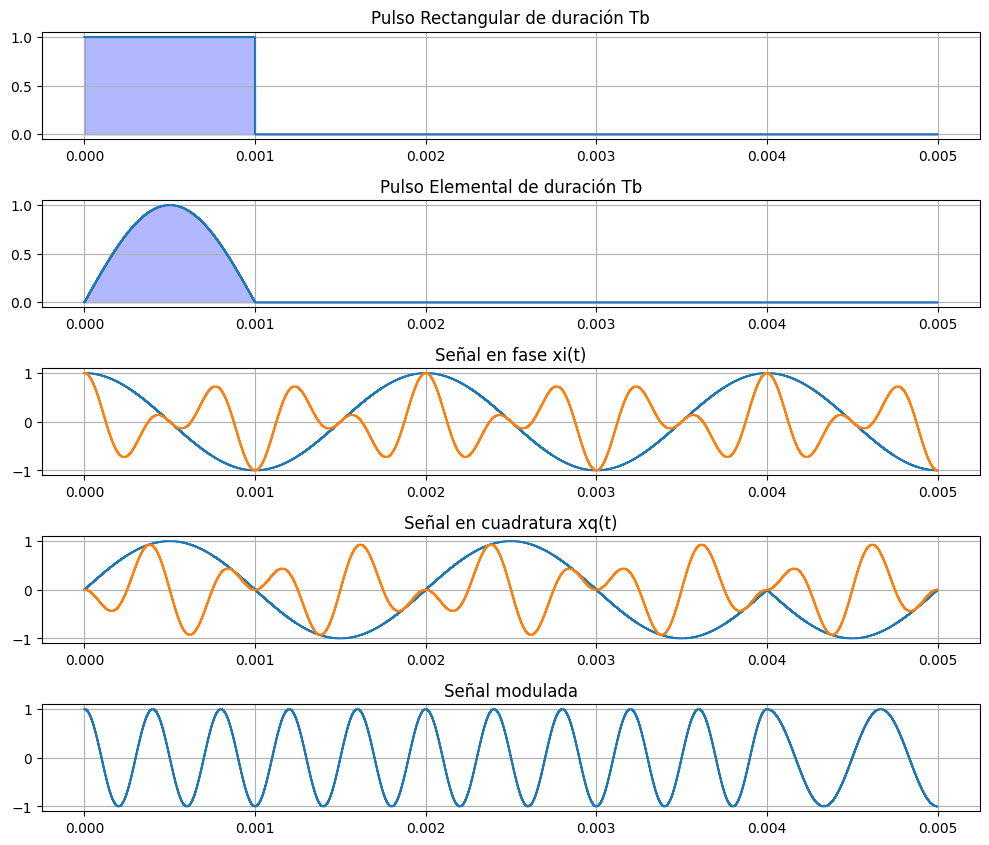

In [72]:
# gráficos
plt.figure(figsize=(10,10))

plt.subplot(6,1,1)
plt.step(t, rectangular, where='post')
plt.fill_between(t, rectangular,color='#0015FA', alpha=0.3)
plt.title("Pulso Rectangular de duración Tb")
plt.grid()


plt.subplot(6,1,2)
plt.step(t, elemental, where='post')
plt.fill_between(t, elemental,color='#0015FA', alpha=0.3)
plt.title("Pulso Elemental de duración Tb")
plt.grid()


plt.subplot(6,1,3)
plt.step(t, x_i, where='post')
plt.step(t, portadora1*x_i, where='post')
plt.title("Señal en fase xi(t)")
plt.grid()


plt.subplot(6,1,4)
plt.step(t, x_q, where='post')
plt.step(t, portadora2*x_q, where='post')
plt.title("Señal en cuadratura xq(t)")
plt.grid()

plt.subplot(6,1,5)

plt.step(t, x_c, where='post')
plt.title("Señal modulada")
plt.grid()

plt.tight_layout()
plt.show()

# Variables estadísticas para el cálculo de la DEP

In [73]:
#Tabla de correspondencia
tabla={}
if formato == 'polar':
    tabla = dict(zip(gray_code(n),[2*i - (M-1) for i in range(M)] ))
else: 
    tabla = dict(zip(gray_code(n), [i for i in range(M)]))
    
for bits,simbolos in tabla.items():
    print(bits, simbolos)


0 -1
1 1


In [74]:
#se obtiene la probabilidad de los símbolos
def get_prob_simbolo(bits, p0, p1):
    prob = 1
    for b in bits:
        if b == '0':
            prob *= p0
        else:
            prob *= p1
    return prob
P_bk = {tabla[bits]: get_prob_simbolo(bits, p0, p1) for bits in tabla}
#Imprime valor de probabilidad asociado a cada simbolo
print("simb.\tprobs")
for simbolo,probabilidad in P_bk.items():
    print(f"{simbolo}\t{probabilidad}")

simb.	probs
-1	0.25
1	0.75


# Media de Qk
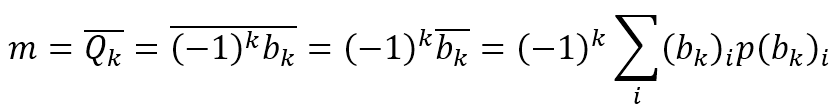

In [75]:
#Determinar la media
def get_media(data): 
    aux=0
    k=len(data)
    for i,v in data.items(): 
        aux+=i*v
    media=((-1)**k)*aux
    return media

m=get_media(P_bk)

print(f'media = {m} ')      
        

media = 0.5 



# Varianza de Qk
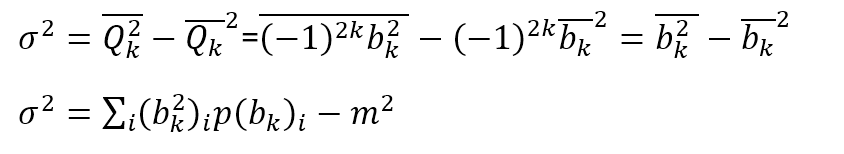

In [76]:
#Determinar valor cuadratico medio
def get_rms(data): 
    rms=0
    for i,v in data.items(): 
        rms+=i*i*v
    return rms
    
#determinar varianza
var=get_rms(P_bk)-m*m

print(f'varianza = {var} ') 

varianza = 0.75 


# Densidad Espectral de Potencia (DEP) M-FSK

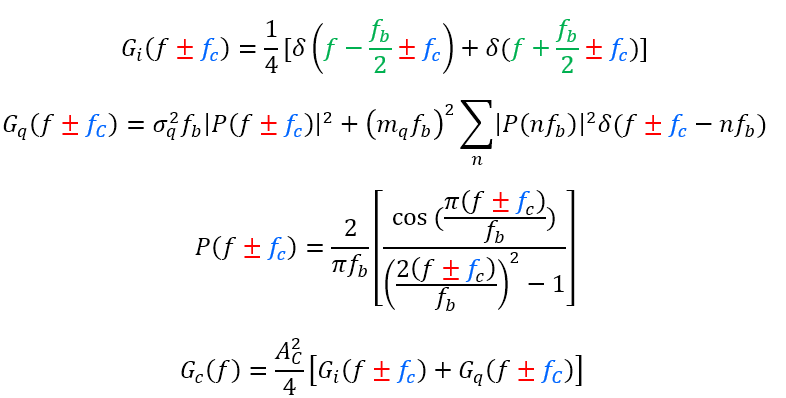

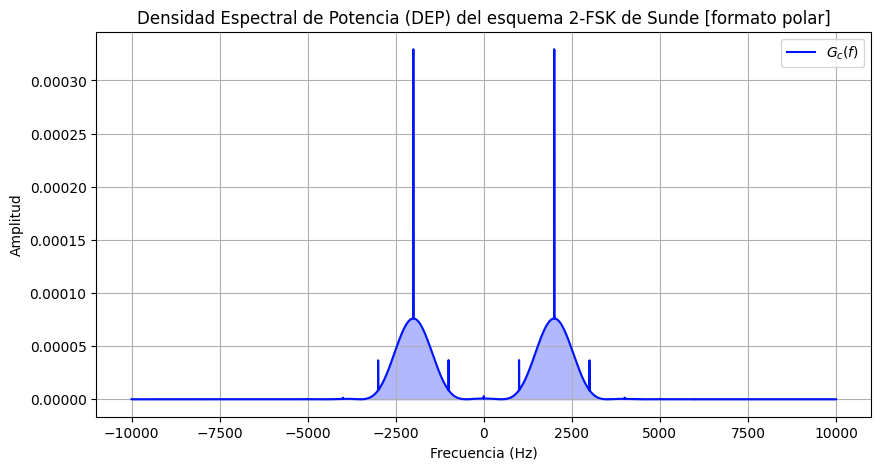

In [77]:
# Vector de frecuencias
f = np.linspace(-10000, 10000, 200000)

def delta(arg):
    delta_signal = np.zeros_like(f)
    idx = np.argmin(np.abs(arg))
    delta_signal[idx] = 1
    return delta_signal

# Transformada de Fourier del pulso elemental
# P(f±fc) = 2/(π*fb) * [cos(π(f±fc)/fb) / ((2(f±fc)/fb)² - 1)]
def P_fourier(freq):
    with np.errstate(divide='ignore', invalid='ignore'):
        numerador = np.cos(np.pi * freq / fb)
        denominador = (2 * freq / fb)**2 - 1
        P = (2 / (np.pi * fb)) * (numerador / denominador)
        # Manejar singularidades
        P = np.nan_to_num(P, nan=0.0, posinf=0.0, neginf=0.0)
    return P

#Atenuar parte discreta solo con fines practicos de visualización (de no hacerlo solo se podrá observar la parte discreta)
At=0.00000001

# Componente en fase: G_i(f±fc) = 1/4 * [δ(f - fb/2 ± fc) + δ(f + fb/2 ± fc)]
G_i_pos = 0.25 * (delta(f - fb/2 - fc) + delta(f + fb/2 - fc))
G_i_neg = 0.25 * (delta(f - fb/2 + fc) + delta(f + fb/2 + fc))
G_i = (G_i_pos + G_i_neg)*At

# Componente en cuadratura: G_q(f±fc)
# Parte continua: σ_q² * fb * |P(f±fc)|²
P_fc_pos = P_fourier(f + fc)
P_fc_neg = P_fourier(f - fc)
G_q_continua = var * fb * (np.abs(P_fc_pos)**2 + np.abs(P_fc_neg)**2)

# Parte discreta: (m_q * fb)² * Σ_n |P(nfb)|² * δ(f±fc - nfb)
# Para n de -10 a 10 (suficiente para la convergencia)
G_q_discreta = np.zeros_like(f)
for n in range(-10, 11):
    P_n = P_fourier(n * fb)
    G_q_discreta += np.abs(P_n)**2 * (delta(f + fc - n*fb) + delta(f - fc - n*fb))
G_q_discreta *= (m * fb)**2

G_q = G_q_continua + G_q_discreta*0.01

# DEP total: Gc(f) = (Ac²/4) * [G_i(f±fc) + G_q(f±fc)]
Gc_f = (Ac**2 / 4) * (G_i + G_q)

plt.figure(figsize=(10, 5))
plt.plot(f, Gc_f, color='#0015FA', label=r'$G_c(f)$')
plt.fill_between(f, Gc_f, color='#0015FA', alpha=0.3)
titulo = f"Densidad Espectral de Potencia (DEP) del esquema {M}-FSK de Sunde [formato {formato}]"
plt.title(titulo)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.show()


In [78]:
np.cos(np.pi)

np.float64(-1.0)

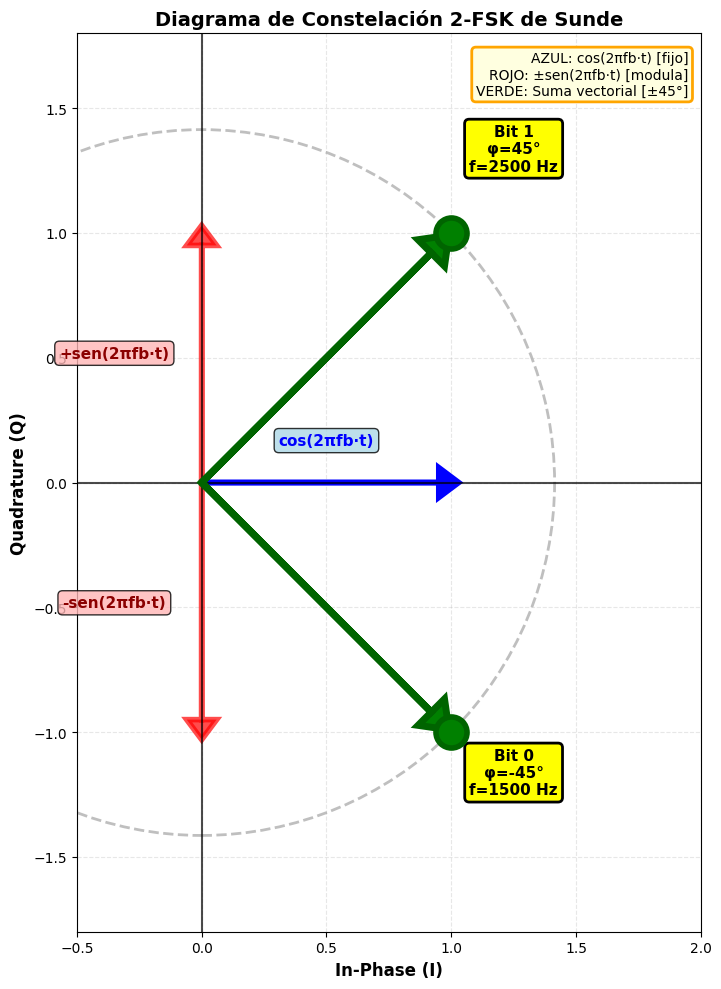

Constelación 2-FSK de Sunde:
  Bit 0: I=1.00, Q=-1.00, φ=-45°, f=1500 Hz
  Bit 1: I=1.00, Q=+1.00, φ=+45°, f=2500 Hz


In [79]:
# Diagrama de constelación FSK de Sunde
# Vector AZUL: cos(2πfb·t) - fijo
# Vectores ROJOS: ±sen(2πfb·t) - modulan con datos
# Vectores VERDES: suma → puntos en ±45°

A = 1

# Vector AZUL fijo
I_azul, Q_azul = A, 0

# Vectores ROJOS modulados (±sen)
vectores_rojos = [(0, -A), (0, A)]  # bk=-1, bk=+1
bits = ['0', '1']
frecuencias = [fc - fb/2, fc + fb/2]

# Vectores VERDES resultantes (suma)
vectores_verdes = [(I_azul, Q_azul + Q_rojo) for _, Q_rojo in vectores_rojos]

# Crear diagrama
fig, ax = plt.subplots(figsize=(10, 10))

# Círculo de referencia
circle = plt.Circle((0, 0), np.sqrt(2)*A, fill=False, color='gray', 
                     linestyle='--', linewidth=2, alpha=0.5)
ax.add_patch(circle)

# Vector AZUL fijo
ax.arrow(0, 0, I_azul*0.95, Q_azul, head_width=0.12, head_length=0.08, 
         fc='blue', ec='blue', linewidth=4, zorder=2)
ax.text(I_azul/2, 0.15, 'cos(2πfb·t)', fontsize=11, color='blue', 
        weight='bold', ha='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Vectores ROJOS y VERDES
for i, (I_r, Q_r) in enumerate(vectores_rojos):
    # Vector ROJO
    ax.arrow(0, 0, I_r, Q_r*0.95, head_width=0.12, head_length=0.08, 
             fc='red', ec='red', linewidth=4, alpha=0.7, zorder=2)
    signo = '+' if Q_r > 0 else '-'
    ax.text(-0.35, Q_r/2, f'{signo}sen(2πfb·t)', fontsize=11, color='darkred', 
            weight='bold', ha='center', bbox=dict(boxstyle='round', facecolor='#FFB6B6', alpha=0.8))
    
    # Vector VERDE resultante
    I_v, Q_v = vectores_verdes[i]
    ax.arrow(0, 0, I_v*0.92, Q_v*0.92, head_width=0.15, head_length=0.1, 
             fc='green', ec='darkgreen', linewidth=5, zorder=4)
    ax.scatter(I_v, Q_v, s=500, c='green', marker='o', 
               edgecolors='darkgreen', linewidths=4, zorder=5)
    
    # Etiqueta
    angle = np.degrees(np.arctan2(Q_v, I_v))
    ax.text(I_v*1.25, Q_v*1.25, f'Bit {bits[i]}\nφ={angle:.0f}°\nf={frecuencias[i]:.0f} Hz', 
            fontsize=11, weight='bold', ha='center', 
            bbox=dict(boxstyle='round', facecolor='yellow', edgecolor='black', linewidth=2))

# Configuración
ax.axhline(0, color='black', linewidth=1.5, alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5, alpha=0.7)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel('In-Phase (I)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quadrature (Q)', fontsize=12, fontweight='bold')
ax.set_title('Diagrama de Constelación 2-FSK de Sunde', fontsize=14, fontweight='bold')
ax.set_xlim([-0.5, 2])
ax.set_ylim([-1.8, 1.8])
ax.set_aspect('equal')

# Info
info = f'AZUL: cos(2πfb·t) [fijo]\nROJO: ±sen(2πfb·t) [modula]\nVERDE: Suma vectorial [±45°]'
ax.text(0.98, 0.98, info, transform=ax.transAxes, fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', linewidth=2))

plt.tight_layout()
plt.show()

print(f"Constelación {M}-FSK de Sunde:")
print(f"  Bit 0: I=1.00, Q=-1.00, φ=-45°, f={fc-fb/2:.0f} Hz")
print(f"  Bit 1: I=1.00, Q=+1.00, φ=+45°, f={fc+fb/2:.0f} Hz")

# Diagrama de Constelación FSK de Sunde